# 10 파이썬 성능 개선

## 10.1 반복문

### 10.1.1 파이썬

In [1]:
import random

In [2]:
def average_py(n):
    s = 0
    for i in range(n):
        s += random.random()
    return s / n

In [3]:
n = 10000000

In [4]:
%time average_py(n)

CPU times: user 679 ms, sys: 10.6 ms, total: 690 ms
Wall time: 690 ms


0.4999092742071877

In [5]:
%timeit average_py(n)

634 ms ± 32.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
%time sum([random.random() for _ in range(n)]) / n

CPU times: user 880 ms, sys: 150 ms, total: 1.03 s
Wall time: 1.04 s


0.500017324500943

### 10.1.2 NumPy

In [7]:
import numpy as np

In [8]:
def average_np(n):
    s = np.random.random(n)
    return s.mean()

In [9]:
%time average_np(n)

CPU times: user 136 ms, sys: 15.4 ms, total: 152 ms
Wall time: 116 ms


np.float64(0.49991810897583944)

In [10]:
%timeit average_np(n)

83.8 ms ± 748 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
s = np.random.random(n)
s.nbytes

80000000

### 10.1.3 Numba

In [12]:
import numba

In [13]:
average_nb = numba.jit(average_py)

In [14]:
%time average_nb(n)

CPU times: user 548 ms, sys: 105 ms, total: 653 ms
Wall time: 801 ms


0.49985219535720515

In [15]:
%time average_nb(n)

CPU times: user 40.5 ms, sys: 478 μs, total: 40.9 ms
Wall time: 40.9 ms


0.5000110226994215

In [16]:
%timeit average_nb(n)

39.4 ms ± 266 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 10.1.4 Cython

In [17]:
%load_ext Cython

In [18]:
%%cython -a
import random
def average_cy1(int n):
    cdef int i
    cdef float s = 0
    for i in range(n):
        s += random.random()
    return s / n

In [19]:
%time average_cy1(n)

CPU times: user 825 ms, sys: 6.98 ms, total: 832 ms
Wall time: 829 ms


0.49990609288215637

In [20]:
%timeit average_cy1(n)

827 ms ± 9.57 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
%%cython
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
cdef int i
cdef float rn
for i in range(5):
    rn = rand() / INT_MAX
    print(rn)

0.3835020661354065
0.5194163918495178
0.8309653401374817
0.03457210958003998
0.05346163362264633


In [22]:
%%cython -a
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
def average_cy2(int n):
    cdef int i
    cdef float s = 0
    for i in range(n):
        s += rand() / INT_MAX
    return s / n

In [23]:
%time average_cy2(n)

CPU times: user 57.6 ms, sys: 868 μs, total: 58.4 ms
Wall time: 58.8 ms


0.500017523765564

In [24]:
%timeit average_cy2(n)

53.8 ms ± 537 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 10.2 알고리즘

## 10.2.1 소수 확인

**파이썬**

In [25]:
def is_prime(I):
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        if I % i == 0: return False
    return True

In [26]:
n = int(1e8 + 3)
n

100000003

In [27]:
%time is_prime(n)

CPU times: user 26 μs, sys: 1e+03 ns, total: 27 μs
Wall time: 29.8 μs


False

In [28]:
p1 = int(1e8 + 7)
p1

100000007

In [29]:
%time is_prime(p1)

CPU times: user 311 μs, sys: 14 μs, total: 325 μs
Wall time: 345 μs


True

In [30]:
p2 = 100109100129162907

In [31]:
p2.bit_length()

57

In [32]:
%time is_prime(p2)

CPU times: user 10.8 s, sys: 21 ms, total: 10.8 s
Wall time: 10.9 s


True

**Numba**

In [33]:
is_prime_nb = numba.jit(is_prime)

In [34]:
%time is_prime_nb(n)

CPU times: user 64.5 ms, sys: 2.75 ms, total: 67.3 ms
Wall time: 66.1 ms


False

In [35]:
%time is_prime_nb(n)

CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 7.87 μs


False

In [36]:
%time is_prime_nb(p1)

CPU times: user 21 μs, sys: 1e+03 ns, total: 22 μs
Wall time: 23.8 μs


True

In [37]:
%time is_prime_nb(p2)

CPU times: user 1.29 s, sys: 8.02 ms, total: 1.3 s
Wall time: 1.29 s


True

**Cython**

In [38]:
%%cython
def is_prime_cy1(I):
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        return False
    return True

In [39]:
%timeit is_prime(p1)

279 μs ± 3.44 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [40]:
%timeit is_prime_cy1(p1)

279 ns ± 1.62 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [41]:
%%cython
def is_prime_cy2(long I):
    cdef long i
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        if I % i == 0: return False
    return True

In [42]:
%timeit is_prime_cy2(p1)

37.8 μs ± 251 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [43]:
%timeit is_prime_nb(p2)

1.29 s ± 9.53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [44]:
%timeit is_prime_cy2(p2)

1.2 s ± 6.82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


**멀티프로세싱**

In [45]:
import multiprocessing as mp

In [46]:
%%time
with mp.get_context('fork').Pool(processes=4) as pool:
    result = pool.map(is_prime, 10 * [p1])
result

CPU times: user 13.9 ms, sys: 22.2 ms, total: 36.2 ms
Wall time: 41.3 ms


[True, True, True, True, True, True, True, True, True, True]

In [47]:
%%time
with mp.get_context('fork').Pool(processes=4) as pool:
    result = pool.map(is_prime_nb, 10 * [p2])
result

CPU times: user 10.3 ms, sys: 22.8 ms, total: 33.1 ms
Wall time: 4.39 s


[True, True, True, True, True, True, True, True, True, True]

In [48]:
%%time
with mp.get_context('fork').Pool(processes=4) as pool:
    result = pool.map(is_prime_cy2, 10 * [p2])
result

CPU times: user 10.9 ms, sys: 30.6 ms, total: 41.5 ms
Wall time: 4.03 s


[True, True, True, True, True, True, True, True, True, True]

### 10.2.2 피보나치 수

**재귀 알고리즘**

In [49]:
def fib_rec_py1(n):
    if n < 2:
        return n
    else:
        return fib_rec_py1(n - 1) + fib_rec_py1(n - 2)

In [50]:
%time fib_rec_py1(35)

CPU times: user 1.35 s, sys: 9.81 ms, total: 1.36 s
Wall time: 1.37 s


9227465

In [51]:
@numba.jit
def fib_rec_nb(n):
    if n < 2:
        return n
    else:
        return fib_rec_nb(n - 1) + fib_rec_nb(n - 2)

In [52]:
%time fib_rec_nb(35)

CPU times: user 121 ms, sys: 6.48 ms, total: 128 ms
Wall time: 126 ms


9227465

In [53]:
%time fib_rec_nb(35)

CPU times: user 68.2 ms, sys: 829 μs, total: 69.1 ms
Wall time: 69.5 ms


9227465

In [54]:
%%cython
def fib_rec_cy(int n):
    if n < 2:
        return n
    else:
        return fib_rec_cy(n - 1) + fib_rec_cy(n - 2)

In [55]:
%time fib_rec_cy(35)

CPU times: user 1.07 s, sys: 14.8 ms, total: 1.08 s
Wall time: 1.1 s


9227465

In [56]:
from functools import lru_cache as cache

In [57]:
@cache(maxsize=None)
def fib_rec_py2(n):
    if n < 2:
        return n
    else:
        return fib_rec_py2(n - 1) + fib_rec_py2(n - 2)

In [58]:
%time fib_rec_py2(35)

CPU times: user 18 μs, sys: 4 μs, total: 22 μs
Wall time: 24.1 μs


9227465

In [59]:
%time fib_rec_py2(80)

CPU times: user 21 μs, sys: 5 μs, total: 26 μs
Wall time: 28.8 μs


23416728348467685

**반복 알고리즘**

In [60]:
def fib_it_py(n):
    x, y = 0, 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [61]:
%time fib_it_py(80)

CPU times: user 13 μs, sys: 1e+03 ns, total: 14 μs
Wall time: 16.9 μs


23416728348467685

In [62]:
fib_it_nb = numba.jit(fib_it_py)

In [63]:
%time fib_it_nb(80)

CPU times: user 48.7 ms, sys: 2.83 ms, total: 51.6 ms
Wall time: 51 ms


23416728348467685

In [64]:
%%cython
def fib_it_cy1(int n):
    cdef long i
    cdef long x = 0, y = 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [65]:
%time fib_it_cy1(80)

CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 6.91 μs


23416728348467685

In [66]:
%%time
fn = fib_rec_py2(150)
print(fn)

9969216677189303386214405760200
CPU times: user 187 μs, sys: 65 μs, total: 252 μs
Wall time: 208 μs


In [67]:
fn.bit_length()

103

In [68]:
%%time
fn = fib_it_nb(150)
print(fn)

6792540214324356296
CPU times: user 76 μs, sys: 8 μs, total: 84 μs
Wall time: 80.8 μs


In [69]:
fn.bit_length()

63

In [70]:
%%time
fb = fib_it_cy1(150)
print(fn)

6792540214324356296
CPU times: user 380 μs, sys: 168 μs, total: 548 μs
Wall time: 402 μs


In [71]:
fn.bit_length()

63

In [72]:
%%cython
cdef extern from *:
    ctypedef int int128 '__int128_t'
def fib_it_cy2(int n):
    cdef int128 i
    cdef int128 x = 0, y = 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [73]:
%%time
fn = fib_it_cy2(150)
print(fn)

9969216677189303386214405760200
CPU times: user 246 μs, sys: 90 μs, total: 336 μs
Wall time: 297 μs


In [74]:
fn.bit_length()

103

### 10.2.3 원주율

In [75]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [76]:
rn = [(random.random() * 2 - 1, random.random() * 2 - 1) for _ in range(500)]

In [77]:
rn = np.array(rn)
rn[:5]

array([[ 0.82707412,  0.68648479],
       [ 0.74165891, -0.70202664],
       [ 0.77434543,  0.74090692],
       [-0.73435894,  0.79643272],
       [ 0.76263651,  0.10616189]])

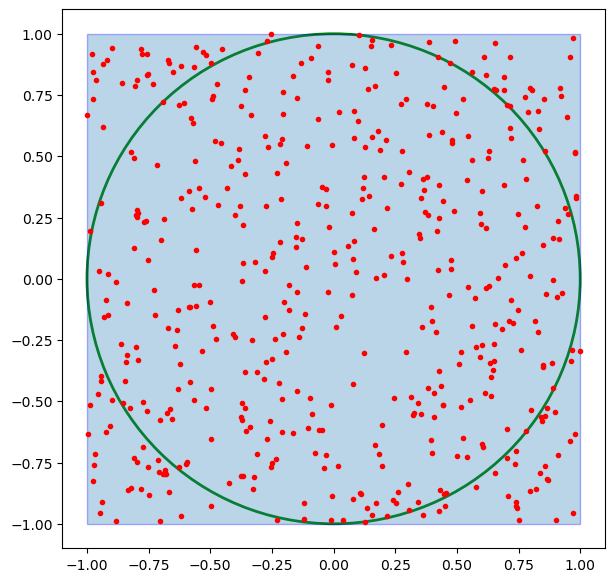

In [78]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1)

circ = plt.Circle((0, 0), radius=1, edgecolor='g', lw=2.0, facecolor='None')
box = plt.Rectangle((-1, -1), 2, 2, edgecolor='b', alpha=0.3)

ax.add_patch(circ)
ax.add_patch(box)

plt.plot(rn[:,0], rn[:,1], 'r.')
plt.ylim(-1.1, 1.1)
plt.xlim(-1.1, 1.1)
plt.show()

In [79]:
n = int(1e7)

In [80]:
%time rn = np.random.random((n, 2)) * 2 - 1

CPU times: user 217 ms, sys: 44.8 ms, total: 262 ms
Wall time: 263 ms


In [81]:
rn.nbytes

160000000

In [82]:
%time distance = np.sqrt((rn ** 2).sum(axis=1))

CPU times: user 216 ms, sys: 119 ms, total: 335 ms
Wall time: 338 ms


In [83]:
%time frac = (distance <= 1.0).sum() / len(distance)

CPU times: user 16.1 ms, sys: 6.06 ms, total: 22.2 ms
Wall time: 19.8 ms


In [84]:
pi_mcs = frac * 4
pi_mcs

np.float64(3.1419704)

In [85]:
%%time
# total amount of time using Numpy
rn = np.random.random((n,2)) * 2 - 1
distance = np.sqrt((rn ** 2).sum(axis=1))
frac = (distance <= 1).sum() / len(distance)
pi_mcs = frac * 4
pi_mcs

CPU times: user 454 ms, sys: 168 ms, total: 623 ms
Wall time: 723 ms


np.float64(3.1412144)

In [86]:
def mcs_pi_py(n):
    circle = 0
    for _ in range(n):
        x, y = random.random(), random.random()
        if (x ** 2 + y ** 2) ** 0.5 <= 1:
            circle += 1
    return (4 * circle) / n

In [87]:
%time mcs_pi_py(n)

CPU times: user 3.23 s, sys: 27.9 ms, total: 3.26 s
Wall time: 3.31 s


3.14226

In [88]:
mcs_pi_nb = numba.jit(mcs_pi_py)

In [89]:
%time mcs_pi_nb(n)

CPU times: user 231 ms, sys: 6.05 ms, total: 237 ms
Wall time: 237 ms


3.1419868

In [90]:
%time mcs_pi_nb(n)

CPU times: user 93.4 ms, sys: 783 μs, total: 94.2 ms
Wall time: 94 ms


3.1426072

In [91]:
%%cython -a
import random
def mcs_pi_cy1(int n):
    cdef i, circle = 0
    cdef float x, y
    for i in range(n):
        x, y = random.random(), random.random()
        if (x ** 2 + y ** 2) <= 1:
            circle += 1
    return (4 * circle) / n

In [92]:
%time mcs_pi_cy1(n)

CPU times: user 1.76 s, sys: 35.6 ms, total: 1.8 s
Wall time: 1.81 s


3.1421416

In [93]:
%%cython -a
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
def mcs_pi_cy2(int n):
    cdef int i, circle = 0
    cdef float x, y
    for i in range(n):
        x, y = rand() / INT_MAX, rand() / INT_MAX
        if (x * x + y * y) <= 1:
            circle += 1
    return circle / n * 4

In [94]:
%time mcs_pi_cy2(n)

CPU times: user 110 ms, sys: 1.5 ms, total: 112 ms
Wall time: 112 ms


3.1419388

## 10.3 이항트리

### 10.3.1 파이썬

In [95]:
import math

In [96]:
S0 = 36.0
T = 1.0
r = 0.06
sigma = 0.2

In [97]:
def simulate_tree(M):
    dt = T / M
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    S = np.zeros((M + 1, M + 1))
    S[0, 0] = S0
    for t in range(1, M + 1):
        for i in range(t):
            S[i, t] = S[i, t-1] * u
            S[i+1, t] = S[i, t-1] * d
    return S

In [98]:
np.set_printoptions(formatter={'float': lambda x: '%6.2f' % x})

In [99]:
simulate_tree(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]])

In [100]:
%time simulate_tree(500)

CPU times: user 83 ms, sys: 3.22 ms, total: 86.2 ms
Wall time: 84.8 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

### 10.3.2 NumPy

In [101]:
M = 4

In [102]:
up = np.arange(M + 1)
up = np.resize(up, (M + 1, M + 1))
up

array([[0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4]])

In [103]:
down = up.T * 2
down

array([[0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [4, 4, 4, 4, 4],
       [6, 6, 6, 6, 6],
       [8, 8, 8, 8, 8]])

In [104]:
up - down

array([[ 0,  1,  2,  3,  4],
       [-2, -1,  0,  1,  2],
       [-4, -3, -2, -1,  0],
       [-6, -5, -4, -3, -2],
       [-8, -7, -6, -5, -4]])

In [105]:
dt = T / M

In [106]:
S0 * np.exp(sigma * math.sqrt(dt) * (up - down))

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [ 29.47,  32.57,  36.00,  39.79,  43.97],
       [ 24.13,  26.67,  29.47,  32.57,  36.00],
       [ 19.76,  21.84,  24.13,  26.67,  29.47],
       [ 16.18,  17.88,  19.76,  21.84,  24.13]])

In [107]:
 def simulate_tree_np(M):
     dt = T / M
     up = np.arange(M + 1)
     up = np.resize(up, (M + 1, M + 1))
     down = up.transpose() * 2
     S = S0 * np.exp(sigma * math.sqrt(dt) * (up - down))
     return S

In [108]:
simulate_tree_np(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [ 29.47,  32.57,  36.00,  39.79,  43.97],
       [ 24.13,  26.67,  29.47,  32.57,  36.00],
       [ 19.76,  21.84,  24.13,  26.67,  29.47],
       [ 16.18,  17.88,  19.76,  21.84,  24.13]])

In [109]:
%time simulate_tree_np(500)

CPU times: user 5.98 ms, sys: 4.4 ms, total: 10.4 ms
Wall time: 9.22 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [ 35.36,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [ 34.73,  35.05,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.41,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.40,   0.41,   0.41]],
      shape=(501, 501))

### 10.3.3 Numba

In [110]:
simulate_tree_nb = numba.jit(simulate_tree)

In [111]:
simulate_tree_nb(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]])

In [112]:
%time simulate_tree_nb(500)

CPU times: user 267 μs, sys: 1e+03 ns, total: 268 μs
Wall time: 271 μs


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

In [113]:
%timeit simulate_tree_nb(500)

167 μs ± 14.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### 10.3.4 Cython

In [114]:
%%cython -a
import numpy as np
from libc.math cimport exp, sqrt
cdef float S0 = 36.0
cdef float T = 1.0
cdef float r = 0.06
cdef float sigma = 0.2
def simulate_tree_cy(int M):
    cdef int t, i
    cdef float dt, u, d
    cdef float[:,:] S = np.zeros((M + 1, M + 1), dtype=np.float32)
    dt = T / M
    u = exp(sigma * sqrt(dt))
    d = 1 / u
    S[0, 0] = S0
    for t in range(1, M + 1):
        for i in range(t):
            S[i, t] = S[i, t-1] * u
            S[i+1, t] = S[i, t-1] * d
    return np.array(S)

In [115]:
simulate_tree_cy(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]], dtype=float32)

In [116]:
%time simulate_tree_cy(500)

CPU times: user 1.25 ms, sys: 1.25 ms, total: 2.51 ms
Wall time: 1.36 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.77, 3123.59, 3151.65],
       [  0.00,  35.68,  36.00, ..., 3040.89, 3068.21, 3095.77],
       [  0.00,   0.00,  35.36, ..., 2986.97, 3013.81, 3040.89],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501), dtype=float32)

In [117]:
%timeit S = simulate_tree_cy(500)

217 μs ± 16.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 10.4 몬테카를로 시뮬레이션

**블랙-숄즈-머튼 확률적 미분방적식(기하 브라운 운동)**

$dS_t = r S_t dt + \sigma S_t dZ_t$,

- $S_t$: $t$ 시점의 기초 자산의 가격
- $r$: 상수, 무위험 이자율
- $\sigma$: 상수, 순간 변동성
- $Z_t$: 브라운 운동

**블랙-숄즈-머튼 이산방적식(오일러 방식)**

$S_t = S_{t - \Delta t} \exp \left( \left( r - \dfrac{\sigma^2}{2} \right) \Delta t + \sigma \sqrt{\Delta t} z \right)$

- 확률적 미분방적식을 동일한 시간 구간으로 나누어 오일러 이산화 방식
- $z$: 표준정규분포 난수
- $T$: 시뮬레이션 전체 시간(평가 대상 옵션의 만기일)
- $\Delta t \equiv \frac{T}{M}$인 $M$개의 시간 구간으로 나눔

**유러피안 콜 옵션에 대한 몬테카를로 추정치**

$C_0 = e^{-rT} \dfrac{1}{I} \sum_{i=1}^{I} \max \left( S_T^{(i)} - K, 0 \right)$

- $S_T$: 만기 $T$까지의 주가 시뮬레이션 값, $I$개의 경로로 시뮬레이션. $(i = 1, 2, \dots, I)$

### 10.4.1 파이썬

In [118]:
M = 100 # 이산화 시간 구간의 개수
I = 50000 # 시뮬레이션할 경로의 개수

In [119]:
def mcs_simulation_py(p):
    M, I = p
    dt = T / M
    S = np.zeros((M + 1, I))
    S[0] = S0
    rn = np.random.standard_normal(S.shape)
    for t in range(1, M + 1):
        for i in range(I):
            S[t, i] = S[t-1, i] * math.exp((r - sigma ** 2 / 2) * dt + sigma * math.sqrt(dt) * rn[t, i])
    return S

In [120]:
%time S = mcs_simulation_py((M, I))

CPU times: user 4.21 s, sys: 86.9 ms, total: 4.3 s
Wall time: 4.7 s


In [121]:
S[-1].mean() # 시뮬레이션에 기반한 만기 값의 평균

np.float64(38.187640716305914)

In [122]:
S0 * math.exp(r * T) # 만기 값의 이론적 기댓값

38.22611567563295

In [123]:
K = 40. # 유러피안 풋 옵션의 행사가

In [124]:
C0 = math.exp(-r * T) * np.maximum(K - S[-1], 0).mean()

In [125]:
C0 # 유러피안 풋 옵션에 대한 몬테카를로 추정치

np.float64(3.843397886959944)

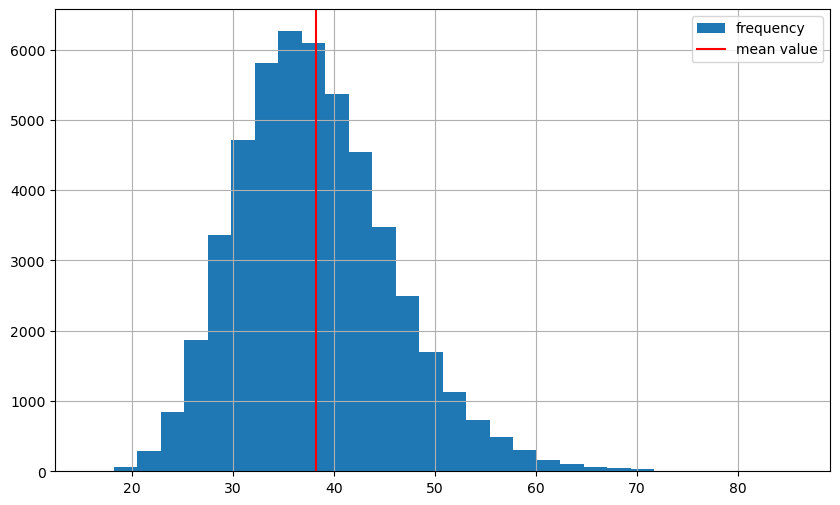

In [126]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1, 1, 1)

ax.hist(S[-1], bins=30, label='frequency')
ax.axvline(S[-1].mean(), color='r', label='mean value')

ax.grid(True)
ax.legend()

plt.show()

### 10.4.2 NumPy

In [127]:
def mcs_simulation_np(p):
    M, I = p
    dt = T / M
    S = np.zeros((M + 1, I))
    S[0] = S0
    rn = np.random.standard_normal(S.shape)
    for t in range(1, M + 1):
        S[t] = S[t-1] * np.exp((r - sigma ** 2 / 2) * dt + sigma * math.sqrt(dt) * rn[t])
    return S

In [128]:
%time S = mcs_simulation_np((M, I))

CPU times: user 204 ms, sys: 20.1 ms, total: 224 ms
Wall time: 224 ms


In [129]:
S[-1].mean()

np.float64(38.2584406107552)

In [130]:
%timeit S = mcs_simulation_np((M, I))

192 ms ± 4.03 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### 10.4.3 Numba

In [131]:
mcs_simulation_nb = numba.jit(mcs_simulation_py)

In [132]:
%time S = mcs_simulation_nb((M, I))

CPU times: user 517 ms, sys: 24.4 ms, total: 542 ms
Wall time: 547 ms


In [133]:
%time S = mcs_simulation_nb((M, I))

CPU times: user 142 ms, sys: 7.59 ms, total: 150 ms
Wall time: 150 ms


In [134]:
S[-1].mean()

np.float64(38.22763100009714)

In [135]:
C0 = math.exp(-r * T) * np.maximum(K - S[-1], 0).mean()

In [136]:
C0

np.float64(3.843253429931829)

In [137]:
%timeit S = mcs_simulation_nb((M, I))

145 ms ± 2.99 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 10.4.4 Cython

In [138]:
%%cython
import numpy as np
cimport cython
from libc.math cimport exp, sqrt
cdef float S0 = 36.
cdef float T = 1.0
cdef float r = 0.06
cdef float sigma = 0.2
@cython.boundscheck(False)
@cython.wraparound(False)
def mcs_simulation_cy(p):
    cdef int M, I
    M, I = p
    cdef int t, i
    cdef float dt = T / M
    cdef double[:,:] S = np.zeros((M + 1, I))
    cdef double[:,:] rn = np.random.standard_normal((M + 1, I))
    S[0] = S0
    for t in range(1, M + 1):
        for i in range(I):
            S[t, i] = S[t-1, i] * exp((r - sigma ** 2 / 2) * dt + sigma * sqrt(dt) * rn[t, i])
    return np.array(S)

In [139]:
%time S = mcs_simulation_cy((M, I))

CPU times: user 189 ms, sys: 11.9 ms, total: 201 ms
Wall time: 199 ms


In [140]:
S[-1].mean()

np.float64(38.23397117475377)

In [141]:
%timeit S = mcs_simulation_cy((M, I))

208 ms ± 19.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### 10.4.5 멀티프로세싱

In [142]:
import multiprocessing as mp

In [143]:
pool = mp.get_context('fork').Pool(processes=4)

In [144]:
p = 20

In [145]:
%timeit S = np.hstack(pool.map(mcs_simulation_np, p * [(M, int(I / p))]))

195 ms ± 16.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [146]:
%timeit S = np.hstack(pool.map(mcs_simulation_nb, p * [(M, int(I / p))]))

180 ms ± 3.55 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [147]:
%timeit S = np.hstack(pool.map(mcs_simulation_cy, p * [(M, int(I / p))]))

190 ms ± 5.79 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [148]:
pool.close()

## 10.5 재귀적 pandas 알고리즘

**지수가중 이동평균(EWMA)**

- $\operatorname{EWMA}_0 = S_0$
- $\operatorname{EWMA}_t = \alpha \cdot S_t + \left( 1 - \alpha \right) \cdot \operatorname{EWMA}_{t-1} , t \in \left\{ 1, \dots, T \right\}$

### 10.5.1 파이썬

In [149]:
import pandas as pd

In [150]:
sym = 'SPY'

In [151]:
data = pd.DataFrame(pd.read_csv('../source/tr_eikon_eod_data.csv',
                                index_col=0, parse_dates=True)[sym]).dropna()

In [152]:
alpha = 0.25

In [153]:
data['EWMA'] = data[sym]

In [154]:
%%time
for t in zip(data.index, data.index[1:]):
    data.loc[t[1], 'EWMA'] = alpha * data.loc[t[1], sym] + (1 - alpha) * data.loc[t[0], 'EWMA']

CPU times: user 484 ms, sys: 5.5 ms, total: 490 ms
Wall time: 491 ms


In [155]:
data.head()

,SPY,EWMA
Date,,
2010-01-04,113.33,113.330000
2010-01-05,113.63,113.405000
2010-01-06,113.71,113.481250
2010-01-07,114.19,113.658438
2010-01-08,114.57,113.886328


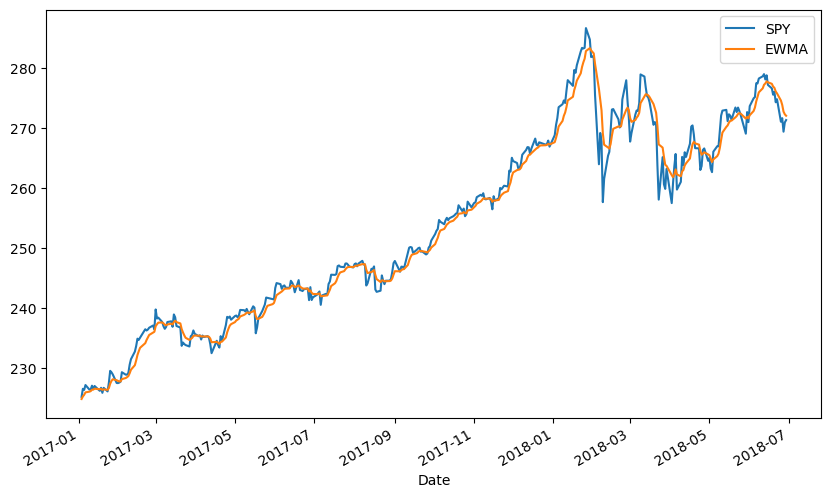

In [156]:
data[data.index > '2017-1-1'].plot(figsize=(10,6))
plt.show()

In [157]:
def ewma_py(x, alpha):
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

In [158]:
%time data['EWMA_PY'] = ewma_py(data[sym], alpha)

CPU times: user 18.4 ms, sys: 2.12 ms, total: 20.5 ms
Wall time: 19.7 ms


/var/folders/y7/n5fkdst51jg1xz7qr3j154qh0000gn/T/ipykernel_34287/4084456606.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y[0] = x[0]
/var/folders/y7/n5fkdst51jg1xz7qr3j154qh0000gn/T/ipykernel_34287/4084456606.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y[i] = alpha * x[i] + (1 - alpha) * y[i-1]


In [159]:
%time data['EWMA_PY'] = ewma_py(data[sym].values, alpha)

CPU times: user 1.18 ms, sys: 17 μs, total: 1.19 ms
Wall time: 1.19 ms


### 10.5.2 Numba

In [160]:
ewma_nb = numba.jit(ewma_py)

In [161]:
%time data['EWMA_NB'] = ewma_nb(data[sym].values, alpha)

CPU times: user 161 ms, sys: 8.53 ms, total: 169 ms
Wall time: 169 ms


In [162]:
%timeit data['EWMA_NB'] = ewma_nb(data[sym].values, alpha)

61.9 μs ± 1.45 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### 10.5.3 Cython

In [163]:
%%cython
import numpy as np
cimport cython
@cython.boundscheck(False)
@cython.wraparound(False)
def ewma_cy(double[:] x, float alpha):
    cdef int i
    cdef double[:] y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return np.array(y)

In [164]:
%time data['EWMA_CY'] = ewma_cy(data[sym].values, alpha)

CPU times: user 1.01 ms, sys: 686 μs, total: 1.7 ms
Wall time: 1.58 ms


In [165]:
%timeit data['EWMA_CY'] = ewma_cy(data[sym].values, alpha)

68.4 μs ± 2.02 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
